# $\mathrm{K}_{\mathrm{V}}2.1$ | WT and mutant experimental-reference RMSD

Here we ask two related questions. First, does targeted masking broaden the
structural ensemble relative to vanilla AlphaFold2? Second, do L403A or F412L models
move toward the experimentally resolved L403A geometry (8SDA) rather than the WT
geometry (8SD3)?

Only models in the established **allOK3** convergence subset are retained. The
v5 RMSD table is then used to remove rows carrying a chain-mapping warning.
This second step is essential because an otherwise cyclically plausible chain
assignment can generate a nonphysical RMSD tail.

In [89]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_root=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'shared').is_dir())
sys.path.insert(0,str(repo_root))
from shared.rmsd_analysis import humanize_measurement,apply_kv21_rmsd_qc
from shared.plotting import ensemble_protocol_palette,experimental_reference_style

SOURCE=repo_root/'kv21/dataRMSD/Kv21_all_models_vs_8SD3_8SDA_RMSD_v5.csv'
CONTACT_SOURCE=repo_root/'kv21/dataRMSD/Kv21_hydrophobic_nexus_contacts_v1_long.csv'
MANIFEST=repo_root/'kv21/dataRMSF/qc/kv21_all_ok3_selection_manifest.csv'
FIG=repo_root/'kv21/dataRMSD/analysis/comparison_v5/figures'
TABLE=repo_root/'kv21/dataRMSD/analysis/comparison_v5'
FIG.mkdir(parents=True,exist_ok=True); TABLE.mkdir(parents=True,exist_ok=True)

REGIONS={
 'full_system_ca_rmsd_A':'Full system',
 'general_tm_rmsd_A':'General TM region',
 's6_bundle_389_422__ca__s1s3_aligned_rmsd_A':'Four-chain S6 bundle',
 'distal_s6_398_414__ca__s1s3_aligned_rmsd_A':'Distal S6',
 'l403_region_398_409__ca__s1s3_aligned_rmsd_A':'L403 region',
 'f412_region_407_417__ca__s1s3_aligned_rmsd_A':'F412 region',
}
POCKETS={f'pocket_{pocket}_ca_rmsd_A':pocket for pocket in 'ABCD'}
TARGET_POCKETS={f'pocket_{pocket}_all_atom_rmsd_A':pocket for pocket in 'ABCD'}
META=['dataset','sequence_condition','protocol','pdb_file','model_path','reference_id',
      'analysis_status','analysis_error','selected_core_postfit_rmsd_A',
      'all24_improvement_over_d4_A','d4_mapping_rmsd_gap_A']
df=pd.read_csv(SOURCE,usecols=META+list(REGIONS)+list(POCKETS)+list(TARGET_POCKETS),low_memory=False)
manifest=pd.read_csv(MANIFEST,usecols=['pdb_basename','all_ok_3'])
selected=set(manifest.loc[manifest.all_ok_3.fillna(False),'pdb_basename'].astype(str))
raw_n=len(df)
df=df[df.pdb_file.astype(str).map(lambda x:Path(x).name).isin(selected)].copy()
allok3_n=len(df)
warning=df[~df.analysis_status.eq('ok')].copy()
df=df[df.analysis_status.eq('ok')].copy()
df=apply_kv21_rmsd_qc(df,repo_root)
df['Sequence']=df.sequence_condition.str.upper()
df['Protocol']=df.protocol.map({'vanilla':'Vanilla','masked':'Masked'})
SEQUENCE_ORDER=['WT','L403A','F412L']
PROTOCOL_ORDER=['Vanilla','Masked']
SEQUENCE_PALETTES={
    sequence:ensemble_protocol_palette('kv21',sequence.lower())
    for sequence in SEQUENCE_ORDER
}
print(f'{raw_n:,} raw reference rows → {allok3_n:,} allOK3 rows → {len(df):,} mapping-QC-passing rows')
print(f'{df.pdb_file.nunique():,} unique models retained')

Kv2.1 structural RMSD QC: 51,742 rows → 48,538 after tetramer/interface QC → 48,538 after excluding 0 separated alignment-failure trajectories (stable-core cutoff 4 Å)
71,988 raw reference rows → 51,804 allOK3 rows → 48,538 mapping-QC-passing rows
24,269 unique models retained


## QC and retained models

The bar height is the number of unique structural snapshots available for each
sequence/protocol combination after both filters. The rejected rows are retained
as a provenance table and are not mixed into any biological comparison.

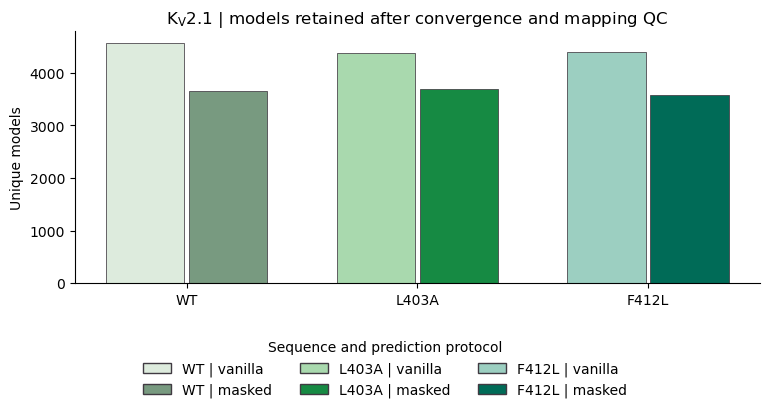

,Sequence,Protocol,models
0,F412L,Masked,3578
1,F412L,Vanilla,4407
2,L403A,Masked,3693
3,L403A,Vanilla,4371
4,WT,Masked,3658
5,WT,Vanilla,4562


In [90]:
counts=df.groupby(['Sequence','Protocol']).pdb_file.nunique().rename('models').reset_index()
counts.to_csv(TABLE/'model_counts_allOK3_mappingQC.csv',index=False)
warning[['sequence_condition','protocol','pdb_file','reference_id','analysis_error',
         'selected_core_postfit_rmsd_A','all24_improvement_over_d4_A']].to_csv(
    TABLE/'excluded_mapping_warning_rows.csv',index=False)
fig,ax=plt.subplots(figsize=(7.8,4.2))
for sequence_index,sequence in enumerate(SEQUENCE_ORDER):
    for protocol in PROTOCOL_ORDER:
        row=counts[(counts.Sequence==sequence)&(counts.Protocol==protocol)]
        if row.empty: continue
        offset=-.18 if protocol=='Vanilla' else .18
        ax.bar(sequence_index+offset,row.models.iloc[0],width=.34,
               color=SEQUENCE_PALETTES[sequence][protocol],
               edgecolor='#403A42',linewidth=.55)
ax.set_xticks(range(len(SEQUENCE_ORDER)),SEQUENCE_ORDER)
ax.set(xlabel='',ylabel='Unique models',
       title=r'$\mathrm{K}_{\mathrm{V}}2.1$ | models retained after convergence and mapping QC')
handles=[
    plt.Rectangle((0,0),1,1,facecolor=SEQUENCE_PALETTES[sequence][protocol],
                  edgecolor='#403A42',label=f'{sequence} | {protocol.lower()}')
    for sequence in SEQUENCE_ORDER for protocol in PROTOCOL_ORDER
]
fig.legend(handles=handles,title='Sequence and prediction protocol',
           loc='lower center',bbox_to_anchor=(.5,.01),ncol=3,frameon=False)
sns.despine(); fig.tight_layout(rect=(0,.22,1,1))
fig.savefig(FIG/'01_retained_models_v5.png',dpi=400,bbox_inches='tight'); plt.show()
display(counts)

## Experimental-reference preference

For every model and region, the paired score is

$$
\Delta_{\mathrm{8SDA-8SD3}} =
\mathrm{RMSD}_{\mathrm{8SDA}}-\mathrm{RMSD}_{\mathrm{8SD3}}.
$$

Negative values indicate greater resemblance to the experimental L403A structure
8SDA; positive values indicate greater resemblance to WT 8SD3. This paired score is
more informative than comparing two independent RMSD distributions because the same
model is evaluated against both references.

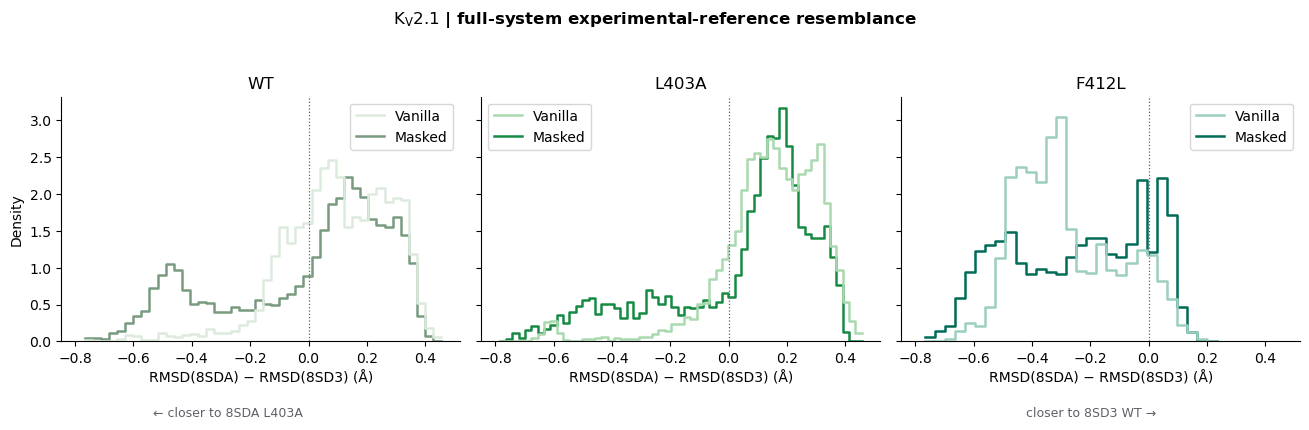

In [91]:
paired_tables=[]
for measurement,label in REGIONS.items():
    identity=['dataset','sequence_condition','Sequence','protocol','Protocol','pdb_file']
    p=df.pivot_table(index=identity,columns='reference_id',values=measurement,aggfunc='first').dropna().reset_index()
    p['delta_8SDA_minus_8SD3_A']=p['8SDA']-p['8SD3']
    p['Region']=label; p['measurement']=measurement
    paired_tables.append(p)
paired=pd.concat(paired_tables,ignore_index=True)
paired.to_csv(TABLE/'paired_reference_preference_by_region_v5.csv',index=False)

focus=paired[paired.Region.eq('Full system')]
fig,axes=plt.subplots(1,3,figsize=(13.2,4.2),sharex=True,sharey=True)
for ax,sequence in zip(axes,SEQUENCE_ORDER):
    part=focus[focus.Sequence.eq(sequence)]
    sns.histplot(data=part,x='delta_8SDA_minus_8SD3_A',hue='Protocol',
                 hue_order=PROTOCOL_ORDER,palette=SEQUENCE_PALETTES[sequence],element='step',fill=False,
                 stat='density',common_norm=False,linewidth=1.8,ax=ax)
    ax.axvline(0,color='#625D68',lw=.9,ls=':')
    ax.set(title=sequence,xlabel='RMSD(8SDA) − RMSD(8SD3) (Å)',ylabel='Density')
    if ax.legend_: ax.legend_.set_title('')
    sns.despine(ax=ax)
fig.suptitle(r'$\mathrm{K}_{\mathrm{V}}2.1$ | full-system experimental-reference resemblance',
             fontweight='semibold')
fig.text(.12,.01,'← closer to 8SDA L403A',ha='left',fontsize=9,color='#625D68')
fig.text(.88,.01,'closer to 8SD3 WT →',ha='right',fontsize=9,color='#625D68')
fig.tight_layout(rect=(0,.05,1,.94))
fig.savefig(FIG/'02_whole_tetramer_reference_preference_v5.png',dpi=400,bbox_inches='tight')
fig.savefig(FIG/'02_whole_tetramer_reference_preference_v5.pdf',bbox_inches='tight')
plt.show()

## Where does the reference preference occur?

The split violins retain the full distribution. They distinguish a global
whole-tetramer resemblance from localized changes in S6 and the hydrophobic
coupling nexus. A mutant can therefore resemble 8SDA globally without reproducing
every local experimental displacement.

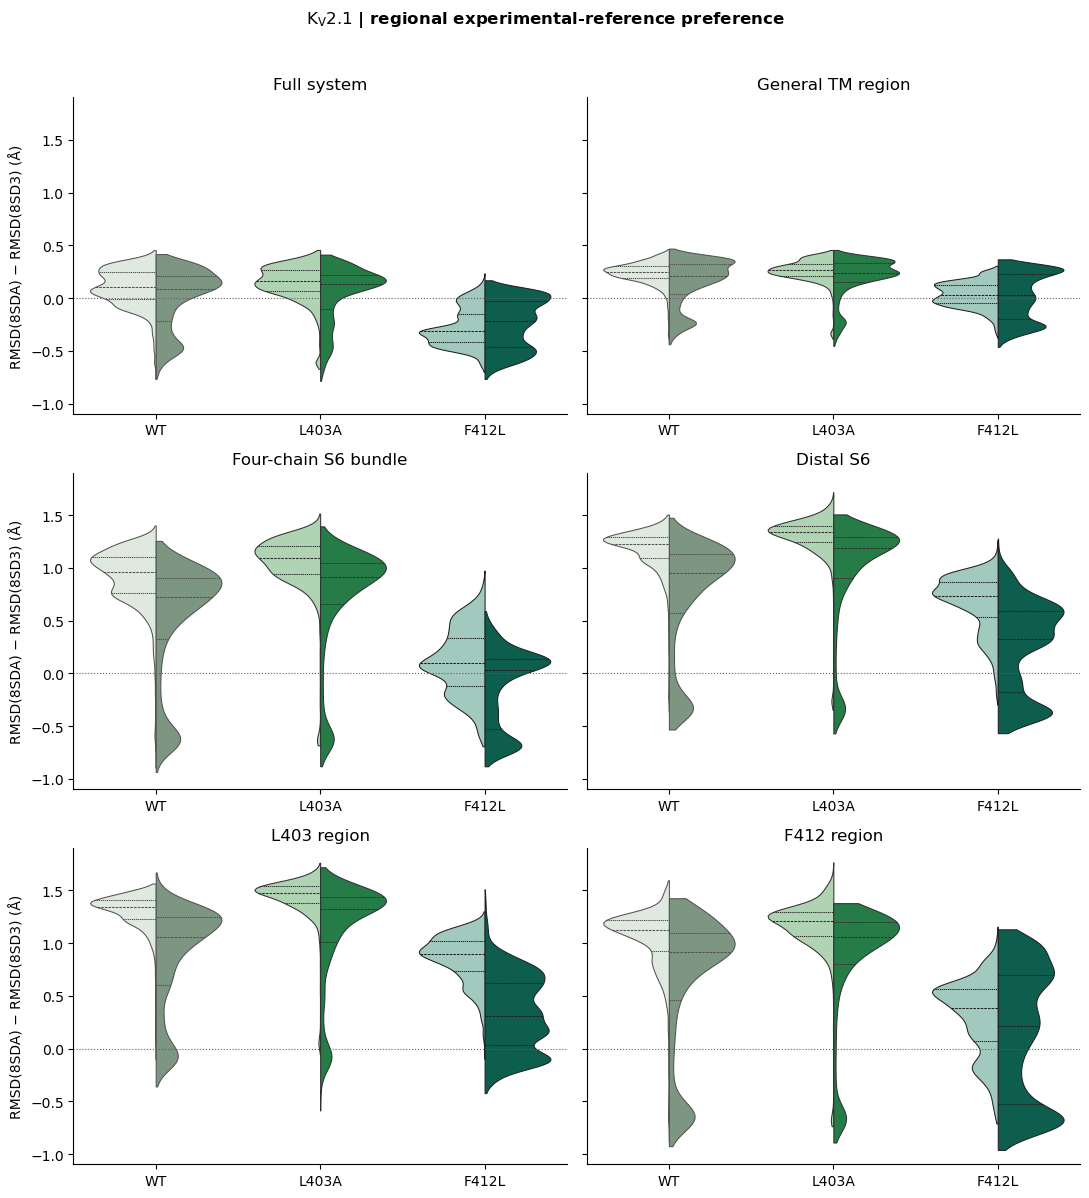

In [92]:
regions=list(REGIONS.values())
fig,axes=plt.subplots(3,2,figsize=(11,12),sharey=True)
for ax,region in zip(axes.flat,regions):
    region_part=paired[paired.Region.eq(region)]
    for sequence in SEQUENCE_ORDER:
        sns.violinplot(data=region_part[region_part.Sequence.eq(sequence)],
                       x='Sequence',y='delta_8SDA_minus_8SD3_A',hue='Protocol',
                       order=SEQUENCE_ORDER,hue_order=PROTOCOL_ORDER,
                       palette=SEQUENCE_PALETTES[sequence],split=True,inner='quart',
                       cut=0,density_norm='width',linewidth=.75,ax=ax,legend=False)
    ax.set(title=region,xlabel='',ylabel='RMSD(8SDA) − RMSD(8SD3) (Å)')
    ax.axhline(0,color='#625D68',lw=.8,ls=':')
    sns.despine(ax=ax)
fig.suptitle(r'$\mathrm{K}_{\mathrm{V}}2.1$ | regional experimental-reference preference',
             fontweight='semibold',y=.995)
fig.tight_layout(rect=(0,0,1,.98))
fig.savefig(FIG/'03_regional_reference_preference_v5.png',dpi=400,bbox_inches='tight')
plt.show()

## Hydrophobic-nexus pockets A–D

Each figure below uses one canonical experimental hydrophobic-nexus pocket and
the globally S1–S3-aligned Cα pocket RMSD. Pockets A–D are retained separately;
they are not raw AlphaFold chain labels and are not averaged. For each model and
pocket, the plotted value is RMSD to 8SDA minus RMSD to 8SD3.

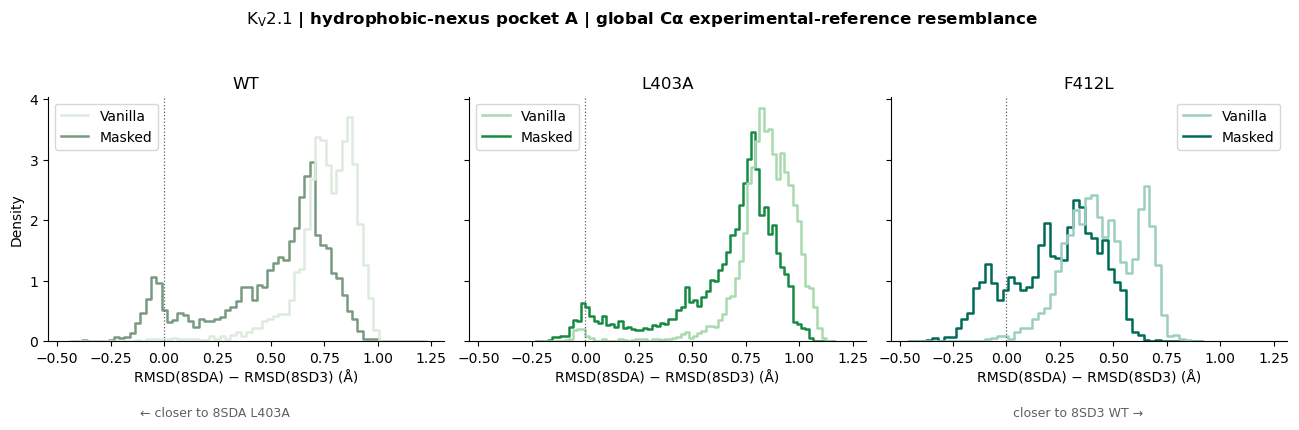

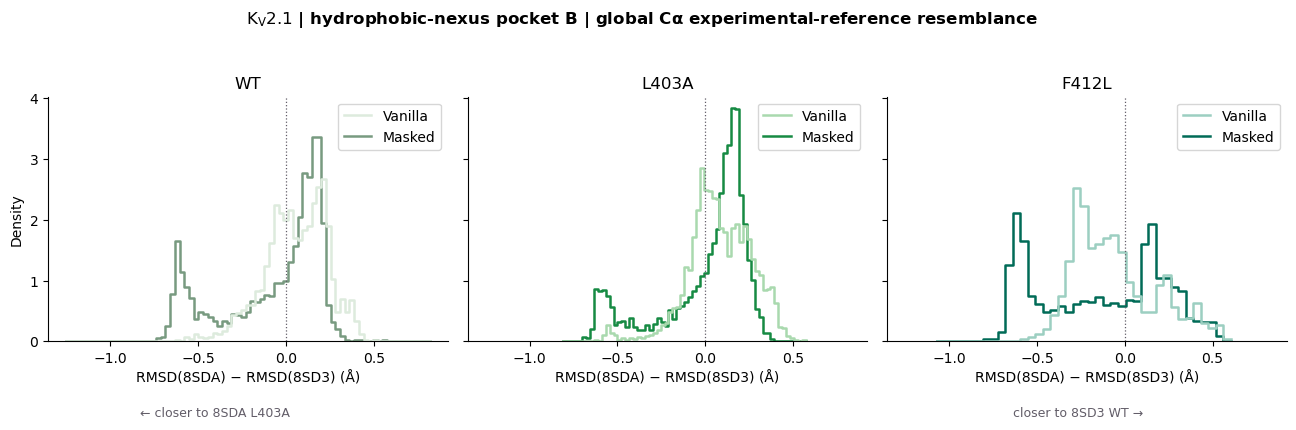

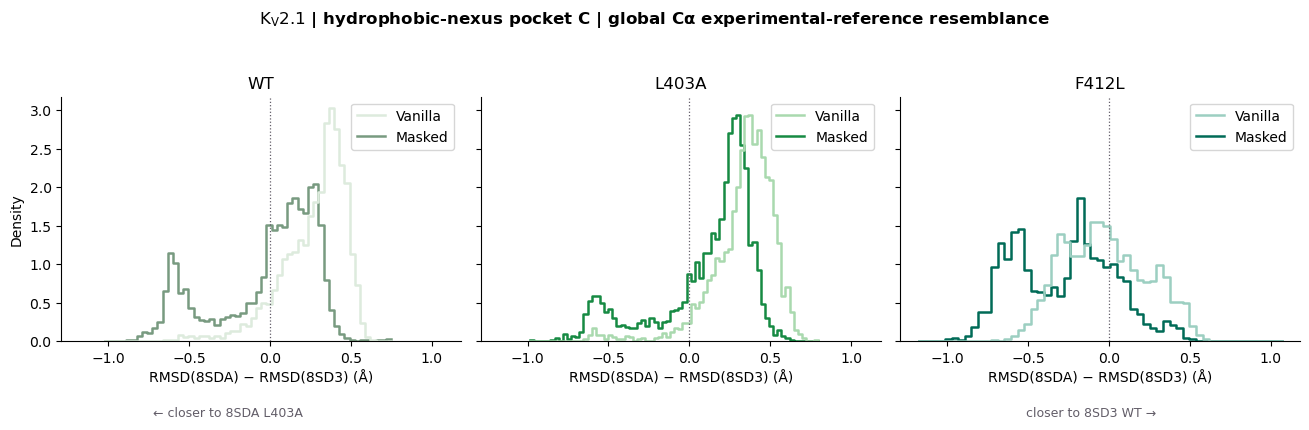

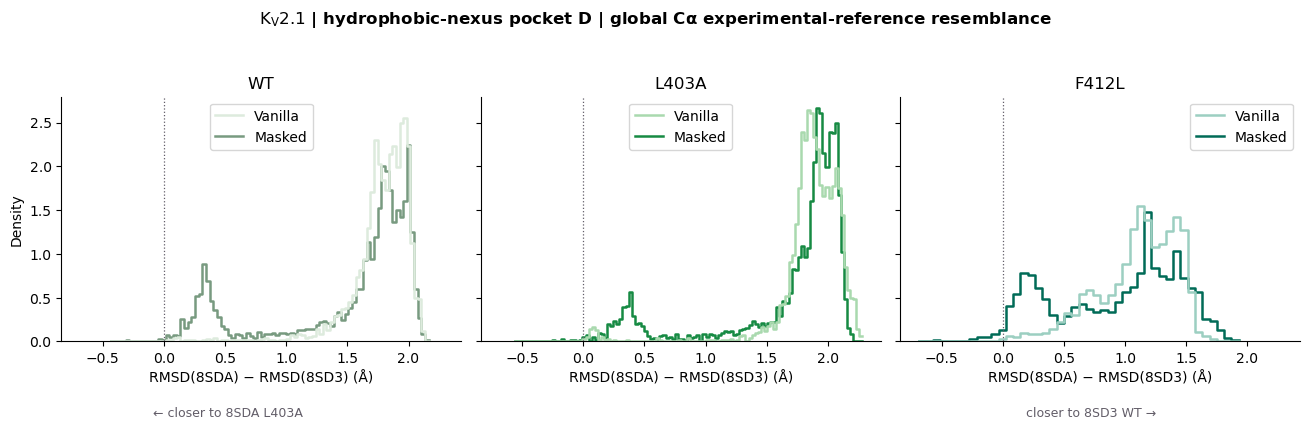

,pocket,Sequence,Protocol,models,median_delta_A,fraction_closer_to_8SDA
0,A,F412L,Masked,3578,0.256349,0.181945
1,A,F412L,Vanilla,4407,0.442210,0.007942
2,A,L403A,Masked,3693,0.736696,0.037368
3,A,L403A,Vanilla,4371,0.855453,0.013040
4,A,WT,Masked,3658,0.587744,0.105796
5,A,WT,Vanilla,4562,0.772537,0.004603
6,B,F412L,Masked,3578,-0.106704,0.562884
7,B,F412L,Vanilla,4407,-0.102630,0.672566
8,B,L403A,Masked,3693,0.098772,0.331438
9,B,L403A,Vanilla,4371,0.072634,0.325326


In [93]:
pocket_long=(df.melt(
    id_vars=['dataset','sequence_condition','Sequence','protocol','Protocol','pdb_file','model_path','reference_id'],
    value_vars=list(POCKETS),var_name='measurement',value_name='pocket_ca_rmsd_A'))
pocket_long['pocket']=pocket_long.measurement.map(POCKETS)
pocket_long.to_csv(TABLE/'hydrophobic_nexus_pocket_ca_long_v5.csv',index=False)

pocket_identity=['dataset','sequence_condition','Sequence','protocol','Protocol','pdb_file','pocket']
pocket_paired=(pocket_long.pivot_table(
    index=pocket_identity,columns='reference_id',values='pocket_ca_rmsd_A',aggfunc='first')
    .dropna(subset=['8SD3','8SDA']).reset_index())
pocket_paired['delta_8SDA_minus_8SD3_A']=pocket_paired['8SDA']-pocket_paired['8SD3']
pocket_paired.to_csv(TABLE/'hydrophobic_nexus_pocket_ca_paired_v5.csv',index=False)

pocket_counts=(pocket_paired.groupby(['pocket','Sequence','Protocol'])
 .agg(models=('pdb_file','nunique'),
      median_delta_A=('delta_8SDA_minus_8SD3_A','median'),
      fraction_closer_to_8SDA=('delta_8SDA_minus_8SD3_A',lambda x:(x<0).mean()))
 .reset_index())
pocket_counts.to_csv(TABLE/'hydrophobic_nexus_pocket_ca_counts_v5.csv',index=False)

for pocket in 'ABCD':
    pocket_part=pocket_paired[pocket_paired.pocket.eq(pocket)]
    fig,axes=plt.subplots(1,3,figsize=(13.2,4.2),sharex=True,sharey=True)
    for ax,sequence in zip(axes,SEQUENCE_ORDER):
        part=pocket_part[pocket_part.Sequence.eq(sequence)]
        sns.histplot(data=part,x='delta_8SDA_minus_8SD3_A',hue='Protocol',
                     hue_order=PROTOCOL_ORDER,palette=SEQUENCE_PALETTES[sequence],
                     element='step',fill=False,stat='density',common_norm=False,
                     linewidth=1.8,ax=ax)
        ax.axvline(0,color='#625D68',lw=.9,ls=':')
        ax.set(title=sequence,xlabel='RMSD(8SDA) − RMSD(8SD3) (Å)',ylabel='Density')
        if ax.legend_: ax.legend_.set_title('')
        sns.despine(ax=ax)
    fig.suptitle(
        rf'$\mathrm{{K}}_{{\mathrm{{V}}}}2.1$ | hydrophobic-nexus pocket {pocket} '
        '| global Cα experimental-reference resemblance',fontweight='semibold')
    fig.text(.12,.01,'← closer to 8SDA L403A',ha='left',fontsize=9,color='#625D68')
    fig.text(.88,.01,'closer to 8SD3 WT →',ha='right',fontsize=9,color='#625D68')
    fig.tight_layout(rect=(0,.05,1,.94))
    stem=f'04_hydrophobic_nexus_pocket_{pocket}_ca_reference_preference_v5'
    fig.savefig(FIG/f'{stem}.png',dpi=400,bbox_inches='tight')
    fig.savefig(FIG/f'{stem}.pdf',bbox_inches='tight')
    plt.show()

display(pocket_counts.sort_values(['pocket','Sequence','Protocol']))

## Which protocol more accurately recreates the hydrophobic nexus?

This is the direct target-reference comparison. WT models are compared with the
matched WT structure 8SD3, and L403A models with the matched L403A structure 8SDA.
F412L has no mutation-matched experimental structure, so its comparison with 8SDA
is labeled only as resemblance to the L403A-like state—not absolute accuracy.

The metric is globally S1–S3-aligned, mutation-aware all-atom pocket RMSD. It
captures both displacement of the pocket relative to the stable core and pocket
repacking. Lower values mean a more accurate recreation. Points are medians; bars
span the interquartile range.

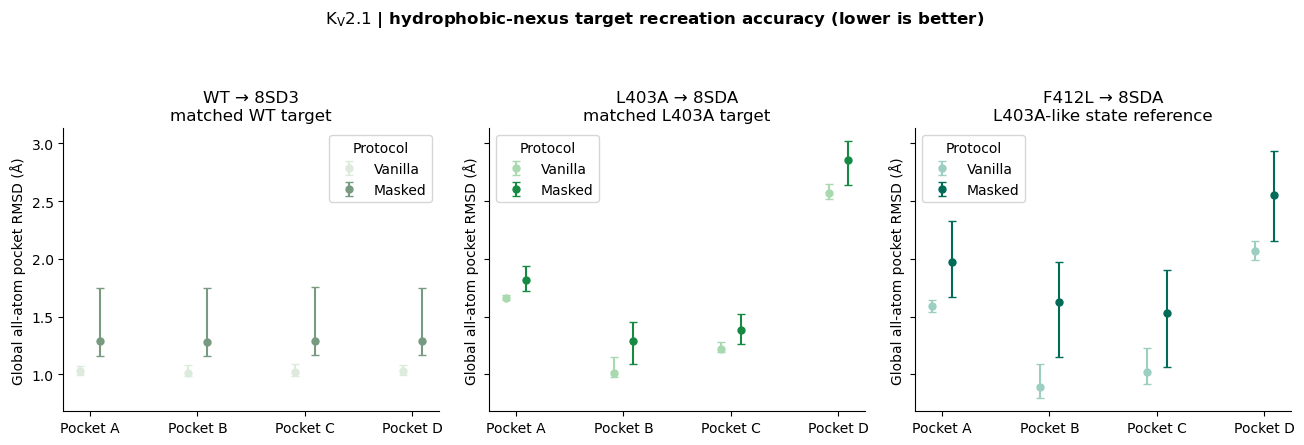

Protocol,Sequence,pocket,reference_id,target_role,Masked,Vanilla,masked_minus_vanilla_median_A
0,F412L,A,8SDA,L403A-like state reference,1.976050,1.589684,0.386366
1,F412L,B,8SDA,L403A-like state reference,1.623671,0.890732,0.732939
2,F412L,C,8SDA,L403A-like state reference,1.528536,1.020209,0.508327
3,F412L,D,8SDA,L403A-like state reference,2.554383,2.070372,0.484012
4,L403A,A,8SDA,matched L403A target,1.819565,1.665254,0.154310
5,L403A,B,8SDA,matched L403A target,1.293470,1.015528,0.277943
6,L403A,C,8SDA,matched L403A target,1.384826,1.224631,0.160195
7,L403A,D,8SDA,matched L403A target,2.852843,2.569673,0.283171
8,WT,A,8SD3,matched WT target,1.287751,1.028938,0.258813
9,WT,B,8SD3,matched WT target,1.282379,1.017268,0.265111


In [94]:
target_reference={'WT':'8SD3','L403A':'8SDA','F412L':'8SDA'}
target_role={'WT':'matched WT target','L403A':'matched L403A target',
             'F412L':'L403A-like state reference'}
target_long=(df.melt(
    id_vars=['dataset','sequence_condition','Sequence','protocol','Protocol','pdb_file','reference_id'],
    value_vars=list(TARGET_POCKETS),var_name='measurement',
    value_name='global_all_atom_pocket_rmsd_A'))
target_long['pocket']=target_long.measurement.map(TARGET_POCKETS)
target_long=target_long[target_long.apply(
    lambda row:row.reference_id==target_reference[row.Sequence],axis=1)].copy()
target_long['target_role']=target_long.Sequence.map(target_role)
target_long.to_csv(TABLE/'hydrophobic_nexus_target_accuracy_all_atom_long_v5.csv',index=False)

target_summary=(target_long.groupby(['Sequence','Protocol','pocket','reference_id','target_role'])
 .agg(models=('pdb_file','nunique'),median_rmsd_A=('global_all_atom_pocket_rmsd_A','median'),
      q25_rmsd_A=('global_all_atom_pocket_rmsd_A',lambda x:x.quantile(.25)),
      q75_rmsd_A=('global_all_atom_pocket_rmsd_A',lambda x:x.quantile(.75)))
 .reset_index())
effect=(target_summary.pivot(index=['Sequence','pocket','reference_id','target_role'],
                             columns='Protocol',values='median_rmsd_A').reset_index())
effect['masked_minus_vanilla_median_A']=effect['Masked']-effect['Vanilla']
effect.to_csv(TABLE/'hydrophobic_nexus_target_accuracy_protocol_effect_v5.csv',index=False)
target_summary.to_csv(TABLE/'hydrophobic_nexus_target_accuracy_all_atom_summary_v5.csv',index=False)

fig,axes=plt.subplots(1,3,figsize=(13.2,4.5),sharey=True)
x=np.arange(4); offsets={'Vanilla':-.09,'Masked':.09}
for ax,sequence in zip(axes,SEQUENCE_ORDER):
    part=target_summary[target_summary.Sequence.eq(sequence)]
    for protocol in PROTOCOL_ORDER:
        rows=(part[part.Protocol.eq(protocol)].set_index('pocket').reindex(list('ABCD')))
        median=rows.median_rmsd_A.to_numpy()
        lower=median-rows.q25_rmsd_A.to_numpy(); upper=rows.q75_rmsd_A.to_numpy()-median
        ax.errorbar(x+offsets[protocol],median,yerr=np.vstack([lower,upper]),fmt='o',
                    ms=5,capsize=3,lw=1.5,color=SEQUENCE_PALETTES[sequence][protocol],
                    label=protocol)
    reference=target_reference[sequence]
    ax.set_xticks(x,[f'Pocket {p}' for p in 'ABCD'])
    ax.set(title=f'{sequence} → {reference}\n{target_role[sequence]}',xlabel='',
           ylabel='Global all-atom pocket RMSD (Å)')
    ax.legend(title='Protocol',frameon=True)
    sns.despine(ax=ax)
fig.suptitle(r'$\mathrm{K}_{\mathrm{V}}2.1$ | hydrophobic-nexus target recreation accuracy '
             '(lower is better)',fontweight='semibold')
fig.tight_layout(rect=(0,0,1,.91))
fig.savefig(FIG/'05_hydrophobic_nexus_target_accuracy_all_atom_v5.png',dpi=400,bbox_inches='tight')
fig.savefig(FIG/'05_hydrophobic_nexus_target_accuracy_all_atom_v5.pdf',bbox_inches='tight')
plt.show()

display(effect.sort_values(['Sequence','pocket']))

## L403A hydrophobic-nexus resemblance to experimental WT and mutant: direct RMSD

This figure removes the signed reference-difference score. It shows the direct
globally aligned, mutation-aware all-atom RMSD between each L403A model pocket and
the corresponding canonical pocket in both **8SD3 (experimental WT Kv2.1)** and
**8SDA (experimental L403A mutant Kv2.1)**. RMSD is nonnegative and reported in Å;
values closer to zero indicate greater structural resemblance.

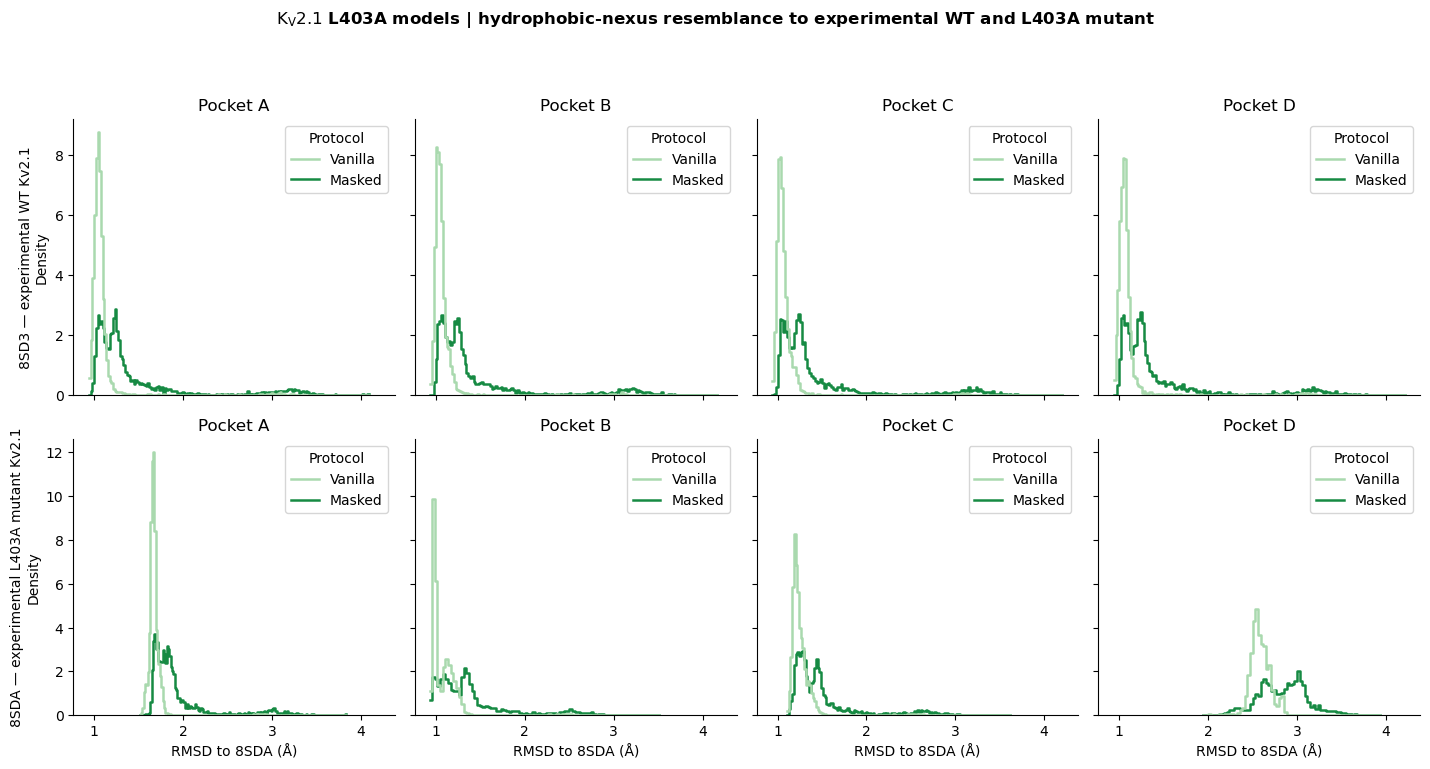

Lowest canonical Pocket-D all-atom RMSD to 8SDA — experimental L403A mutant Kv2.1:
/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/l403a/vanilla/kv21_l403a_unrelaxed_alphafold2_multimer_v3_model_1_seed_132.r2.pdb
RMSD: 1.946 Å (Vanilla)

Best Pocket-D model within each protocol:
Protocol                                                                                                                                          model_path  global_all_atom_pocket_rmsd_A
  Masked /quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/l403a/masked/models/kv21_l403a_masked_unrelaxed_rank_041_alphafold2_multimer_v3_model_4_seed_106.r2.pdb                       1.991488
 Vanilla                       /quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/l403a/vanilla/kv21_l403a_unrelaxed_alphafold2_multimer_v3_model_1_seed_132.r2.pdb                       1.946149


In [95]:
l403a_reference_long=(df[df.Sequence.eq('L403A')].melt(
    id_vars=['dataset','sequence_condition','Sequence','protocol','Protocol','pdb_file','model_path','reference_id'],
    value_vars=list(TARGET_POCKETS),var_name='measurement',
    value_name='global_all_atom_pocket_rmsd_A'))
l403a_reference_long['pocket']=l403a_reference_long.measurement.map(TARGET_POCKETS)
l403a_reference_long.to_csv(
    TABLE/'l403a_hydrophobic_nexus_direct_rmsd_WT_and_mutant_references_v5.csv',index=False)

reference_labels={
    '8SD3':'8SD3 — experimental WT Kv2.1',
    '8SDA':'8SDA — experimental L403A mutant Kv2.1',
}
fig,axes=plt.subplots(2,4,figsize=(14.4,7.8),sharex=True,sharey='row')
for row,reference in enumerate(['8SD3','8SDA']):
    for col,pocket in enumerate('ABCD'):
        ax=axes[row,col]
        part=l403a_reference_long[
            l403a_reference_long.reference_id.eq(reference)
            & l403a_reference_long.pocket.eq(pocket)]
        sns.histplot(data=part,x='global_all_atom_pocket_rmsd_A',hue='Protocol',
                     hue_order=PROTOCOL_ORDER,palette=SEQUENCE_PALETTES['L403A'],
                     element='step',fill=False,stat='density',common_norm=False,
                     linewidth=1.8,ax=ax)
        ax.set(title=f'Pocket {pocket}',xlabel=f'RMSD to {reference} (Å)',
               ylabel=reference_labels[reference]+'\nDensity' if col==0 else '')
        if ax.legend_: ax.legend_.set_title('Protocol')
        sns.despine(ax=ax)
fig.suptitle(r'$\mathrm{K}_{\mathrm{V}}2.1$ L403A models | hydrophobic-nexus resemblance '
             'to experimental WT and L403A mutant',fontweight='semibold')
fig.tight_layout(rect=(0,0,1,.93))
fig.savefig(FIG/'06_l403a_hydrophobic_nexus_direct_rmsd_WT_vs_mutant_v5.png',
            dpi=400,bbox_inches='tight')
fig.savefig(FIG/'06_l403a_hydrophobic_nexus_direct_rmsd_WT_vs_mutant_v5.pdf',
            bbox_inches='tight')
plt.show()

pocket_d_8sda=(l403a_reference_long[
    l403a_reference_long.reference_id.eq('8SDA')
    & l403a_reference_long.pocket.eq('D')]
    .sort_values('global_all_atom_pocket_rmsd_A'))
best_pocket_d=pocket_d_8sda.head(1)
best_pocket_d_by_protocol=(pocket_d_8sda.groupby('Protocol',sort=False)
                           .head(1).sort_values('Protocol'))
print('Lowest canonical Pocket-D all-atom RMSD to 8SDA — experimental L403A mutant Kv2.1:')
print(best_pocket_d['model_path'].iloc[0])
print(f"RMSD: {best_pocket_d['global_all_atom_pocket_rmsd_A'].iloc[0]:.3f} Å "
      f"({best_pocket_d['Protocol'].iloc[0]})")
print('\nBest Pocket-D model within each protocol:')
print(best_pocket_d_by_protocol[
    ['Protocol','model_path','global_all_atom_pocket_rmsd_A']].to_string(index=False))

## Paper-defined hydrophobic-nexus contacts in canonical Pocket D

The nexus is centered on **F412**. The three paper-defined measurements are F412–L316
within the same subunit and F412–L329 plus F412–L403/A403 across the mapped neighboring
subunit. Chain identities come from each model's stable v5 pocket mapping; a fixed raw
chain letter is not assumed to be the neighbor.

The first single-panel figure shows shortest heavy-atom distances, which most directly
report contact formation. Experimental markers show canonical Pocket D from **8SD3
(experimental WT Kv2.1)** and **8SDA (experimental L403A mutant Kv2.1)**.

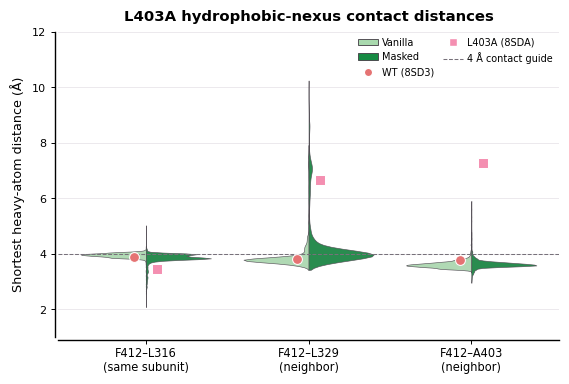

In [96]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

short_columns={
 'F412–L316\n(same subunit)':'F412_L316_same_chain_shortest_heavy_atom_distance_A',
 'F412–L329\n(neighbor)':'F412_L329_neighbor_shortest_heavy_atom_distance_A',
 'F412–A403\n(neighbor)':'F412_L403_or_A403_neighbor_shortest_heavy_atom_distance_A',
}
identity=['source_type','dataset','sequence_condition','protocol','pdb_file',
          'model_path','canonical_pocket']
nexus=pd.read_csv(CONTACT_SOURCE,usecols=identity+list(short_columns.values()),low_memory=False)
experimental_nexus=nexus[nexus.source_type.eq('experimental_reference') &
                         nexus.canonical_pocket.eq('D')].copy()
model_nexus=nexus[nexus.source_type.eq('alphafold_model') &
                  nexus.sequence_condition.eq('l403a') &
                  nexus.canonical_pocket.eq('D')].copy()
retained=set(df.loc[df.Sequence.eq('L403A'),'pdb_file'].astype(str).map(lambda x:Path(x).name))
model_nexus=model_nexus[model_nexus.pdb_file.astype(str).map(lambda x:Path(x).name).isin(retained)].copy()
model_nexus['Protocol']=model_nexus.protocol.map({'vanilla':'Vanilla','masked':'Masked'})
short_order=list(short_columns)
short_long=(model_nexus.rename(columns={v:k for k,v in short_columns.items()})
 .melt(id_vars=['Protocol','pdb_file','model_path'],value_vars=short_order,
       var_name='Contact',value_name='Shortest heavy-atom distance (Å)'))
short_long.to_csv(TABLE/'l403a_pocket_D_paper_nexus_shortest_contacts_long_v5.csv',index=False)

reference_styles={r:experimental_reference_style(r) for r in ['8SD3','8SDA']}
reference_labels={'8SD3':'WT (8SD3)','8SDA':'L403A (8SDA)'}
with sns.plotting_context('paper',font_scale=1.0):
 fig,ax=plt.subplots(figsize=(5.7,3.85),facecolor='white')
sns.violinplot(data=short_long,x='Contact',y='Shortest heavy-atom distance (Å)',
 hue='Protocol',order=short_order,hue_order=PROTOCOL_ORDER,
 palette=SEQUENCE_PALETTES['L403A'],split=True,inner=None,cut=0,
 density_norm='width',bw_adjust=.65,linewidth=.45,saturation=.92,ax=ax,legend=False)
for body in ax.collections:
 body.set_edgecolor('#514B53'); body.set_linewidth(.45); body.set_alpha(.94)
for xpos,(label,column) in enumerate(short_columns.items()):
 for reference,offset in [('8SD3',-.07),('8SDA',.07)]:
  row=experimental_nexus[experimental_nexus.dataset.eq(reference)].iloc[0]
  style=reference_styles[reference]
  ax.scatter(xpos+offset,row[column],color=style['color'],marker=style['marker'],
             s=50,zorder=6,edgecolor='white',linewidth=.75)
ax.axhline(4,color='#77717A',lw=.75,ls='--',zorder=1)
ax.set_ylim(1,12); ax.set_axisbelow(True)
ax.yaxis.grid(True,color='#E7E3E8',linewidth=.55); ax.xaxis.grid(False)
ax.tick_params(axis='x',labelsize=8.2,pad=3,width=.7,length=3)
ax.tick_params(axis='y',labelsize=8,width=.7,length=3)
ax.set(xlabel='',ylabel='Shortest heavy-atom distance (Å)')
ax.set_ylabel('Shortest heavy-atom distance (Å)',fontsize=9.2,labelpad=5)
ax.set_title('L403A hydrophobic-nexus contact distances',fontsize=10.7,
             fontweight='semibold',pad=8)
legend_handles=[Patch(facecolor=SEQUENCE_PALETTES['L403A'][p],edgecolor='#403A42',
                linewidth=.6,label=p)
                for p in PROTOCOL_ORDER]
legend_handles += [Line2D([0],[0],marker=reference_styles[r]['marker'],linestyle='none',
 markerfacecolor=reference_styles[r]['color'],markeredgecolor='white',markersize=6,
 label=reference_labels[r]) for r in ['8SD3','8SDA']]
legend_handles.append(Line2D([0],[0],color='#77717A',ls='--',lw=.75,label='4 Å contact guide'))
ax.legend(handles=legend_handles,loc='upper right',bbox_to_anchor=(.995,.995),
 ncol=2,columnspacing=.9,handletextpad=.45,fontsize=7.0,frameon=False,borderaxespad=0)
sns.despine(ax=ax,offset=2,trim=False); fig.tight_layout(pad=.75)
l403a_short_stem=FIG/'07_l403a_pocket_D_paper_nexus_shortest_contact_violins_v5'
fig.savefig(l403a_short_stem.with_suffix('.png'),dpi=800,bbox_inches='tight',facecolor='white')
fig.savefig(l403a_short_stem.with_suffix('.tiff'),dpi=600,bbox_inches='tight',facecolor='white',pil_kwargs={'compression':'tiff_lzw'})
fig.savefig(l403a_short_stem.with_suffix('.pdf'),bbox_inches='tight',facecolor='white')
fig.savefig(l403a_short_stem.with_suffix('.svg'),bbox_inches='tight',facecolor='white')
plt.show()

## Cα geometry and best experimental-mutant contact recreation

The Cα version reports backbone-scale rearrangement for the same mapped residue pairs.
It is less direct than shortest heavy-atom distance for deciding whether a contact is
formed, but more stable to side-chain rotamers. The ranking below uses the three
shortest-heavy-atom distances and is a **contact-pattern RMSE**, not pocket RMSD.

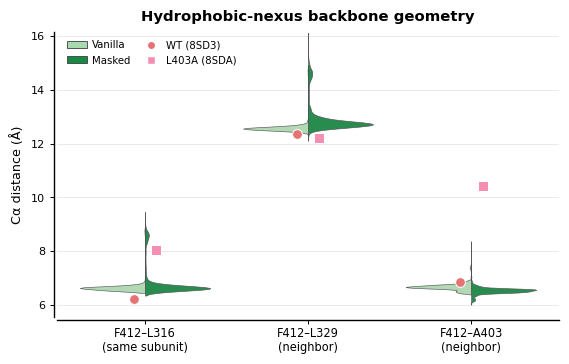

,Protocol,model_path,contact_distance_rmse_to_8SDA_A,F412_L316_same_chain_shortest_heavy_atom_distance_A,F412_L329_neighbor_shortest_heavy_atom_distance_A,F412_L403_or_A403_neighbor_shortest_heavy_atom_distance_A
49175,Masked,/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/l4...,1.548,4.731,4.985,5.609
74395,Vanilla,/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/l4...,1.550,3.709,7.678,4.801


Full path of best masked canonical Pocket-D contact-pattern recreation of 8SDA:
/quobyte/yarovoygrp/ahgz/vgic_mutants/Kv2.1/l403a/masked/models/kv21_l403a_masked_unrelaxed_rank_051_alphafold2_multimer_v3_model_4_seed_071.r3.pdb
Three-contact shortest-heavy-atom RMSE: 1.548 Å


In [97]:
ca_columns={
 'F412–L316\n(same subunit)':'F412_L316_same_chain_ca_distance_A',
 'F412–L329\n(neighbor)':'F412_L329_neighbor_ca_distance_A',
 'F412–A403\n(neighbor)':'F412_L403_or_A403_neighbor_ca_distance_A',
}
ca_source=pd.read_csv(CONTACT_SOURCE,usecols=identity+list(ca_columns.values()),low_memory=False)
ca_models=ca_source[ca_source.source_type.eq('alphafold_model') &
 ca_source.sequence_condition.eq('l403a') & ca_source.canonical_pocket.eq('D')].copy()
ca_models=ca_models[ca_models.pdb_file.astype(str).map(lambda x:Path(x).name).isin(retained)]
ca_models['Protocol']=ca_models.protocol.map({'vanilla':'Vanilla','masked':'Masked'})
ca_order=list(ca_columns)
ca_long=(ca_models.rename(columns={v:k for k,v in ca_columns.items()})
 .melt(id_vars=['Protocol','pdb_file','model_path'],value_vars=ca_order,
       var_name='Contact',value_name='Cα distance (Å)'))
ca_long.to_csv(TABLE/'l403a_pocket_D_paper_nexus_ca_distances_long_v5.csv',index=False)
ca_experimental=ca_source[ca_source.source_type.eq('experimental_reference') &
                          ca_source.canonical_pocket.eq('D')]
with sns.plotting_context('paper',font_scale=1.0):
 fig,ax=plt.subplots(figsize=(5.7,3.65),facecolor='white')
sns.violinplot(data=ca_long,x='Contact',y='Cα distance (Å)',hue='Protocol',
 order=ca_order,hue_order=PROTOCOL_ORDER,palette=SEQUENCE_PALETTES['L403A'],
 split=True,inner=None,cut=0,density_norm='width',bw_adjust=.65,
 linewidth=.45,saturation=.92,ax=ax,legend=False)
for body in ax.collections:
 body.set_edgecolor('#514B53')
 body.set_linewidth(.45)
 body.set_alpha(.94)
for xpos,(label,column) in enumerate(ca_columns.items()):
 for reference,offset in [('8SD3',-.07),('8SDA',.07)]:
  row=ca_experimental[ca_experimental.dataset.eq(reference)].iloc[0]
  style=reference_styles[reference]
  ax.scatter(xpos+offset,row[column],color=style['color'],marker=style['marker'],
             s=50,zorder=6,edgecolor='white',linewidth=.75)
ax.set(xlabel='',ylabel='Cα distance (Å)',
 title='Hydrophobic-nexus backbone geometry')
ax.set_ylim(5.55,16.15)
ax.set_axisbelow(True)
ax.yaxis.grid(True,color='#E7E3E8',linewidth=.55)
ax.xaxis.grid(False)
ax.tick_params(axis='x',labelsize=8.2,pad=3,width=.7,length=3)
ax.tick_params(axis='y',labelsize=8,width=.7,length=3)
ax.set_ylabel('Cα distance (Å)',fontsize=9.2,labelpad=5)
ax.set_title('Hydrophobic-nexus backbone geometry',fontsize=10.7,fontweight='semibold',pad=8)
compact_handles=[
 Patch(facecolor=SEQUENCE_PALETTES['L403A'][p],edgecolor='#403A42',linewidth=.6,label=p)
 for p in PROTOCOL_ORDER]
compact_handles += [Line2D([0],[0],marker=reference_styles[r]['marker'],linestyle='none',
 markerfacecolor=reference_styles[r]['color'],markeredgecolor='white',markersize=6,
 label=('WT (8SD3)' if r=='8SD3' else 'L403A (8SDA)')) for r in ['8SD3','8SDA']]
ax.legend(handles=compact_handles,loc='upper left',bbox_to_anchor=(.012,.985),
 ncol=2,columnspacing=1.0,handletextpad=.5,fontsize=7.3,frameon=False,borderaxespad=0)
sns.despine(ax=ax,offset=2,trim=False)
fig.tight_layout(pad=.75)
panel_stem=FIG/'08_l403a_pocket_D_paper_nexus_ca_distance_violins_v5'
fig.savefig(panel_stem.with_suffix('.png'),dpi=800,bbox_inches='tight',facecolor='white')
fig.savefig(panel_stem.with_suffix('.tiff'),dpi=600,bbox_inches='tight',facecolor='white',pil_kwargs={'compression':'tiff_lzw'})
fig.savefig(panel_stem.with_suffix('.pdf'),bbox_inches='tight',facecolor='white')
fig.savefig(panel_stem.with_suffix('.svg'),bbox_inches='tight',facecolor='white')
plt.show()

reference_8sda=experimental_nexus[experimental_nexus.dataset.eq('8SDA')].iloc[0]
observed=model_nexus[list(short_columns.values())].apply(pd.to_numeric,errors='coerce')
target=reference_8sda[list(short_columns.values())].astype(float)
model_nexus['contact_distance_rmse_to_8SDA_A']=np.sqrt(observed.sub(target,axis='columns').pow(2).mean(axis=1))
best_contacts=(model_nexus.sort_values('contact_distance_rmse_to_8SDA_A')
 .groupby('Protocol',sort=False).head(1).sort_values('Protocol'))
best_contacts.to_csv(TABLE/'l403a_best_pocket_D_paper_nexus_contact_matches_to_8SDA_v5.csv',index=False)
display(best_contacts[['Protocol','model_path','contact_distance_rmse_to_8SDA_A']+
                      list(short_columns.values())].round(3))
best_masked=best_contacts[best_contacts.Protocol.eq('Masked')].iloc[0]
print('Full path of best masked canonical Pocket-D contact-pattern recreation of 8SDA:')
print(best_masked.model_path)
print(f"Three-contact shortest-heavy-atom RMSE: {best_masked.contact_distance_rmse_to_8SDA_A:.3f} Å")

---

# F412L mutant | separate hydrophobic-nexus analysis

**The analysis now switches from L403A to the other Kv2.1 mutant, F412L.**

## Canonical Pocket-D backbone geometry

The corrected table also contains all three mapped nexus distances for F412L. In
these models the central residue is **L412**, so the labels below reflect the actual
mutant identity.

> **Reference limitation:** no experimental F412L structure was reported. The 8SD3
> WT and 8SDA L403A markers are shown only as contextual experimental geometries;
> neither is an experimental F412L target.

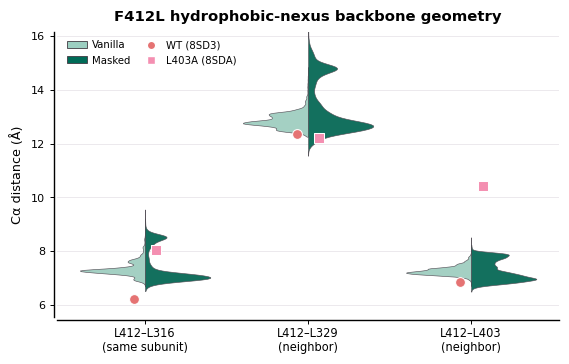

F412L canonical Pocket-D models plotted: 7,985


In [98]:
f412l_retained=set(df.loc[df.Sequence.eq('F412L'),'pdb_file'].astype(str)
                    .map(lambda x:Path(x).name))
f412l_ca=ca_source[ca_source.source_type.eq('alphafold_model') &
 ca_source.sequence_condition.eq('f412l') & ca_source.canonical_pocket.eq('D')].copy()
f412l_ca=f412l_ca[f412l_ca.pdb_file.astype(str).map(lambda x:Path(x).name).isin(f412l_retained)]
f412l_ca['Protocol']=f412l_ca.protocol.map({'vanilla':'Vanilla','masked':'Masked'})
f412l_labels={
 'L412–L316\n(same subunit)':'F412_L316_same_chain_ca_distance_A',
 'L412–L329\n(neighbor)':'F412_L329_neighbor_ca_distance_A',
 'L412–L403\n(neighbor)':'F412_L403_or_A403_neighbor_ca_distance_A',
}
f412l_order=list(f412l_labels)
f412l_long=(f412l_ca.rename(columns={v:k for k,v in f412l_labels.items()})
 .melt(id_vars=['Protocol','pdb_file','model_path'],value_vars=f412l_order,
       var_name='Contact',value_name='Cα distance (Å)'))
f412l_long.to_csv(TABLE/'f412l_pocket_D_paper_nexus_ca_distances_long_v5.csv',index=False)

with sns.plotting_context('paper',font_scale=1.0):
 fig,ax=plt.subplots(figsize=(5.7,3.65),facecolor='white')
sns.violinplot(data=f412l_long,x='Contact',y='Cα distance (Å)',hue='Protocol',
 order=f412l_order,hue_order=PROTOCOL_ORDER,palette=SEQUENCE_PALETTES['F412L'],
 split=True,inner=None,cut=0,density_norm='width',bw_adjust=.65,
 linewidth=.45,saturation=.92,ax=ax,legend=False)
for body in ax.collections:
 body.set_edgecolor('#514B53'); body.set_linewidth(.45); body.set_alpha(.94)
for xpos,(label,column) in enumerate(f412l_labels.items()):
 for reference,offset in [('8SD3',-.07),('8SDA',.07)]:
  row=ca_experimental[ca_experimental.dataset.eq(reference)].iloc[0]
  style=reference_styles[reference]
  ax.scatter(xpos+offset,row[column],color=style['color'],marker=style['marker'],
             s=50,zorder=6,edgecolor='white',linewidth=.75)
ax.set_ylim(5.55,16.15); ax.set_axisbelow(True)
ax.yaxis.grid(True,color='#E7E3E8',linewidth=.55); ax.xaxis.grid(False)
ax.tick_params(axis='x',labelsize=8.2,pad=3,width=.7,length=3)
ax.tick_params(axis='y',labelsize=8,width=.7,length=3)
ax.set(xlabel='',ylabel='Cα distance (Å)')
ax.set_ylabel('Cα distance (Å)',fontsize=9.2,labelpad=5)
ax.set_title('F412L hydrophobic-nexus backbone geometry',fontsize=10.7,
             fontweight='semibold',pad=8)
f412l_handles=[Patch(facecolor=SEQUENCE_PALETTES['F412L'][p],
 edgecolor='#403A42',linewidth=.6,label=p) for p in PROTOCOL_ORDER]
f412l_handles += [Line2D([0],[0],marker=reference_styles[r]['marker'],linestyle='none',
 markerfacecolor=reference_styles[r]['color'],markeredgecolor='white',markersize=6,
 label=('WT (8SD3)' if r=='8SD3' else 'L403A (8SDA)')) for r in ['8SD3','8SDA']]
ax.legend(handles=f412l_handles,loc='upper left',bbox_to_anchor=(.012,.985),
 ncol=2,columnspacing=1.0,handletextpad=.5,fontsize=7.3,frameon=False,borderaxespad=0)
sns.despine(ax=ax,offset=2,trim=False); fig.tight_layout(pad=.75)
f412l_stem=FIG/'09_f412l_pocket_D_paper_nexus_ca_distance_violins_v5'
fig.savefig(f412l_stem.with_suffix('.png'),dpi=800,bbox_inches='tight',facecolor='white')
fig.savefig(f412l_stem.with_suffix('.tiff'),dpi=600,bbox_inches='tight',facecolor='white',pil_kwargs={'compression':'tiff_lzw'})
fig.savefig(f412l_stem.with_suffix('.pdf'),bbox_inches='tight',facecolor='white')
fig.savefig(f412l_stem.with_suffix('.svg'),bbox_inches='tight',facecolor='white')
plt.show()
print(f"F412L canonical Pocket-D models plotted: {f412l_ca.model_path.nunique():,}")

## Canonical Pocket-D shortest heavy-atom contacts

Shortest heavy-atom distance tests whether the L412-centered nexus residues actually
form contacts. The figure focuses on 1–12 Å so the contact-forming and partially
disengaged populations remain visible. Rare longer-distance loss-of-contact states
are retained without clipping in the exported long-form CSV.

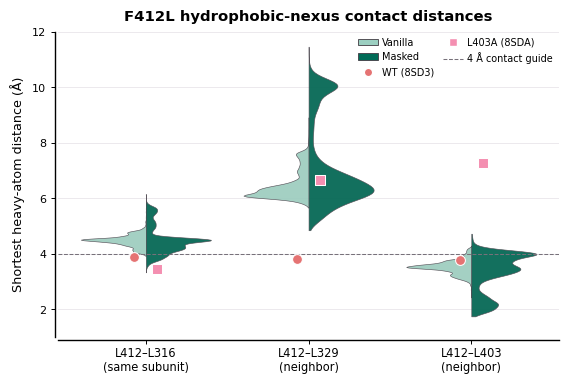

In [99]:
f412l_short_labels={
 'L412–L316\n(same subunit)':'F412_L316_same_chain_shortest_heavy_atom_distance_A',
 'L412–L329\n(neighbor)':'F412_L329_neighbor_shortest_heavy_atom_distance_A',
 'L412–L403\n(neighbor)':'F412_L403_or_A403_neighbor_shortest_heavy_atom_distance_A',
}
f412l_short=nexus[nexus.source_type.eq('alphafold_model') &
 nexus.sequence_condition.eq('f412l') & nexus.canonical_pocket.eq('D')].copy()
f412l_short=f412l_short[f412l_short.pdb_file.astype(str).map(lambda x:Path(x).name)
                         .isin(f412l_retained)]
f412l_short['Protocol']=f412l_short.protocol.map({'vanilla':'Vanilla','masked':'Masked'})
f412l_short_order=list(f412l_short_labels)
f412l_short_long=(f412l_short.rename(columns={v:k for k,v in f412l_short_labels.items()})
 .melt(id_vars=['Protocol','pdb_file','model_path'],value_vars=f412l_short_order,
       var_name='Contact',value_name='Shortest heavy-atom distance (Å)'))
f412l_short_long.to_csv(TABLE/'f412l_pocket_D_paper_nexus_shortest_contacts_long_v5.csv',index=False)

with sns.plotting_context('paper',font_scale=1.0):
 fig,ax=plt.subplots(figsize=(5.7,3.85),facecolor='white')
sns.violinplot(data=f412l_short_long,x='Contact',y='Shortest heavy-atom distance (Å)',
 hue='Protocol',order=f412l_short_order,hue_order=PROTOCOL_ORDER,
 palette=SEQUENCE_PALETTES['F412L'],split=True,inner=None,cut=0,
 density_norm='width',bw_adjust=.65,linewidth=.45,saturation=.92,ax=ax,legend=False)
for body in ax.collections:
 body.set_edgecolor('#514B53'); body.set_linewidth(.45); body.set_alpha(.94)
for xpos,(label,column) in enumerate(f412l_short_labels.items()):
 for reference,offset in [('8SD3',-.07),('8SDA',.07)]:
  row=experimental_nexus[experimental_nexus.dataset.eq(reference)].iloc[0]
  style=reference_styles[reference]
  ax.scatter(xpos+offset,row[column],color=style['color'],marker=style['marker'],
             s=50,zorder=6,edgecolor='white',linewidth=.75)
ax.axhline(4,color='#77717A',lw=.75,ls='--',zorder=1)
ax.set_ylim(1,12); ax.set_axisbelow(True)
ax.yaxis.grid(True,color='#E7E3E8',linewidth=.55); ax.xaxis.grid(False)
ax.tick_params(axis='x',labelsize=8.2,pad=3,width=.7,length=3)
ax.tick_params(axis='y',labelsize=8,width=.7,length=3)
ax.set(xlabel='',ylabel='Shortest heavy-atom distance (Å)')
ax.set_ylabel('Shortest heavy-atom distance (Å)',fontsize=9.2,labelpad=5)
ax.set_title('F412L hydrophobic-nexus contact distances',fontsize=10.7,
             fontweight='semibold',pad=8)
short_handles=f412l_handles+[Line2D([0],[0],color='#77717A',ls='--',lw=.75,
                                    label='4 Å contact guide')]
ax.legend(handles=short_handles,loc='upper right',bbox_to_anchor=(.995,.995),
 ncol=2,columnspacing=.9,handletextpad=.45,fontsize=7.0,frameon=False,borderaxespad=0)
sns.despine(ax=ax,offset=2,trim=False); fig.tight_layout(pad=.75)
f412l_short_stem=FIG/'10_f412l_pocket_D_paper_nexus_shortest_contact_violins_v5'
fig.savefig(f412l_short_stem.with_suffix('.png'),dpi=800,bbox_inches='tight',facecolor='white')
fig.savefig(f412l_short_stem.with_suffix('.tiff'),dpi=600,bbox_inches='tight',facecolor='white',pil_kwargs={'compression':'tiff_lzw'})
fig.savefig(f412l_short_stem.with_suffix('.pdf'),bbox_inches='tight',facecolor='white')
fig.savefig(f412l_short_stem.with_suffix('.svg'),bbox_inches='tight',facecolor='white')
plt.show()

## Descriptive summary

Fractions are calculated per structural snapshot. Because recycle snapshots from
one trajectory are correlated, these values describe ensemble occupancy and are not
treated as independent-sample probabilities.

In [100]:
summary=(paired.groupby(['Region','Sequence','Protocol'])
 .agg(n=('pdb_file','size'),
      median_delta_A=('delta_8SDA_minus_8SD3_A','median'),
      p05_delta_A=('delta_8SDA_minus_8SD3_A',lambda x:x.quantile(.05)),
      p95_delta_A=('delta_8SDA_minus_8SD3_A',lambda x:x.quantile(.95)),
      fraction_closer_to_8SDA=('delta_8SDA_minus_8SD3_A',lambda x:(x<0).mean()))
 .reset_index())
summary.to_csv(TABLE/'reference_preference_summary_v5.csv',index=False)
display(summary.sort_values(['Region','Sequence','Protocol']))

,Region,Sequence,Protocol,n,median_delta_A,p05_delta_A,p95_delta_A,fraction_closer_to_8SDA
0,Distal S6,F412L,Masked,3578,0.329080,-0.413261,0.859824,0.327557
1,Distal S6,F412L,Vanilla,4407,0.738035,0.166407,0.981746,0.019968
2,Distal S6,L403A,Masked,3693,1.187366,-0.344361,1.383470,0.111562
3,Distal S6,L403A,Vanilla,4371,1.336576,1.032912,1.501520,0.016930
4,Distal S6,WT,Masked,3658,0.956110,-0.362772,1.261862,0.175232
5,Distal S6,WT,Vanilla,4562,1.228608,0.818971,1.379522,0.007014
6,F412 region,F412L,Masked,3578,0.215169,-0.727008,1.000152,0.404416
7,F412 region,F412L,Vanilla,4407,0.385864,-0.331975,0.792255,0.217835
8,F412 region,L403A,Masked,3693,1.062619,-0.666170,1.296960,0.130788
9,F412 region,L403A,Vanilla,4371,1.207471,0.815421,1.450327,0.020590
